# Benchmark NX-heuristic init -- forced max-length vs natural shortest-paths

For each Mumford city (`Mumford0`..`Mumford3`) we build the NX-heuristic
initial route network two ways and plot them **side-by-side**:

* **`max_only`** (left) -- every route is **exactly `spec.max_route_len`
  stops** long, via the standard `build_nx_heuristic_routes` (the library
  invariant: shortest paths that are too short get padded by
  `extend_route_to_max_len`). This is what the §12 benchmark sweep starts
  every method from.
* **`variable`** (right) -- routes are **raw shortest paths** whose
  natural length falls in `[2, spec.max_route_len]`. No padding -- short
  shortest paths stay short. Length varies route-to-route. Notebook-local
  helper, because the library always pads to `max_len`.

The contrast surfaces a fundamental design choice of the benchmark init:
it pads to keep route tensors uniform-shape, but the natural shortest-path
distribution in these graphs is much shorter than `max_len`. Long routes
in the `max_only` panel are mostly the random-walk extension layered on
top of a much shorter shortest-path "spine".

Both builds share `BENCHMARK_NX_SEED = 0`. Outputs:

* `artifacts/results/benchmark_init_diagnostics.csv` -- two rows per city
  with the full length distribution and stop coverage.
* Figures shown inline.

## 1. Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# eval_lib must be importable -- the notebook's working directory holds it.
import os as _os, sys as _sys
_NB_DIR = _os.path.abspath(".")
if _NB_DIR not in _sys.path:
    _sys.path.insert(0, _NB_DIR)
import eval_lib
from eval_lib import *  # noqa: F401,F403
from eval_lib import plots as _plots

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

print("eval_lib OK; RESULTS_DIR =", RESULTS_DIR.relative_to(ROOT_DIR))
print(f"Available BENCHMARK_SPECS ({len(BENCHMARK_SPECS)}):")
for spec in BENCHMARK_SPECS:
    print(f"  {spec['city']:<10} n_routes={spec['n_routes']:>3} "
          f"min_len={spec['min_route_len']:>2} max_len={spec['max_route_len']:>2}")

eval_lib OK; RESULTS_DIR = artifacts\results
Available BENCHMARK_SPECS (5):
  Mandl      n_routes=  6 min_len= 2 max_len= 8
  Mumford0   n_routes= 12 min_len= 2 max_len=15
  Mumford1   n_routes= 15 min_len=10 max_len=30
  Mumford2   n_routes= 56 min_len=10 max_len=22
  Mumford3   n_routes= 60 min_len=12 max_len=25


## 2. Configuration

`CITIES` lists which benchmarks to visualize (defaults to all 4 Mumford
instances; Mandl is included for completeness but tiny). `NX_SEED` matches
`BENCHMARK_NX_SEED` in `eval_lib/baselines.py` -- change it only to
inspect a non-default init. `SHOW_OVERLAP_CURVES` is `True` so routes
sharing the same edge fan out as arcs instead of hiding under one
another.

In [2]:
CITIES = ["Mumford0", "Mumford1", "Mumford2", "Mumford3"]
NX_SEED = 0   # matches BENCHMARK_NX_SEED in eval_lib/baselines.py
SHOW_OVERLAP_CURVES = True

# Filter BENCHMARK_SPECS down to the chosen cities, preserving order.
city_to_spec = {spec["city"]: spec for spec in BENCHMARK_SPECS}
SELECTED_SPECS = [city_to_spec[c] for c in CITIES if c in city_to_spec]
print(f"Selected cities ({len(SELECTED_SPECS)}):")
for spec in SELECTED_SPECS:
    print(f"  {spec['city']:<10} n_routes={spec['n_routes']:>3} "
          f"min_len={spec['min_route_len']:>2} max_len={spec['max_route_len']:>2} "
          f"seed={NX_SEED}")

Selected cities (4):
  Mumford0   n_routes= 12 min_len= 2 max_len=15 seed=0
  Mumford1   n_routes= 15 min_len=10 max_len=30 seed=0
  Mumford2   n_routes= 56 min_len=10 max_len=22 seed=0
  Mumford3   n_routes= 60 min_len=12 max_len=25 seed=0


## 3. Build NX-heuristic routes + LC + RPC (four variants)

For each city we run four builds:

* **`max_only`**: standard `build_nx_heuristic_routes(min_len = max_len =
  spec.max_route_len)`. All routes exactly `spec.max_route_len` stops;
  shorter shortest-paths get random-walk padded.
* **`variable`**: notebook-local `build_variable_length_routes`. Raw
  shortest paths with length in `[2, spec.max_route_len]`, no padding.
* **`lc`**: `run_lc(cfg, tensors=tensors, n_samples=1)` -- a SINGLE
  stochastic sample from the trained construction model
  `bestsofar_feb2023` (i.e. LC-1, not LC-100). Routes vary in length
  (the model emits halt actions internally). Diagnostic mode: shows
  what one fresh sample looks like, rather than the cost-optimised
  best-of-100 production setting. Skipped if `MODEL_WEIGHTS_PATH` is
  missing locally.
* **`rpc`**: same `run_lc(..., n_samples=1)` plumbing but with
  `model=random_path_combiner` overriding the trained construction
  model. RPC = `RandomPathCombiningRouteGenerator` -- the paper's
  pi_random: composes random shortest paths without any learned policy.
  Visualises what construction looks like before training contributes
  anything. Cost is typically much worse than LC-1 (3-4x on Mumford0).

In [3]:
import random
import networkx as nx
from hydra import initialize_config_dir, compose

from connectpt.routes_generator import CityGraphData, build_nx_heuristic_routes
from connectpt.routes_generator.nx_heuristic import (
    build_street_graph, node_degree_probabilities, roulette_choice,
    canonical_route, route_is_new,
)
from connectpt.routes_generator.torch_utils import get_batch_tensor_from_routes
# eval_lib wildcard-import skips underscore-prefixed names, so pull this one
# explicitly -- _safe_rpc below needs it to inject DISABLED_COST_COMPONENTS
# into the RPC-cfg the same way other cfg-builders do.
from eval_lib import _apply_disabled_components_to_cfg


def build_variable_length_routes(city_graph, num_routes, min_len, max_len,
                                  seed=0, route_attempts=60):
    """Raw NX shortest paths with length in [min_len, max_len] -- no
    `extend_route_to_max_len`. Each route stays at its natural shortest-
    path length; the final tensor is padded to max_len with -1.

    Uses the same NX primitives the library's build_nx_heuristic_routes
    uses, minus the extension step -- so the picker (degree-roulette
    endpoints + duplicate-avoiding pool) matches the library."""
    graph_nx = build_street_graph(city_graph)
    rng = random.Random(seed)
    candidate_paths = {}
    for source, path_dict in nx.all_pairs_shortest_path(graph_nx):
        for target, path in path_dict.items():
            if source == target or not (min_len <= len(path) <= max_len):
                continue
            candidate_paths[(int(source), int(target))] = list(path)
    probabilities = node_degree_probabilities(graph_nx)
    routes, used_routes = [], set()
    for _ in range(num_routes):
        selected = None
        for _ in range(route_attempts):
            s = roulette_choice(probabilities, rng)
            t = roulette_choice(probabilities, rng)
            if s == t:
                continue
            path = candidate_paths.get((s, t))
            if path is None or not route_is_new(path, used_routes):
                continue
            selected = path
            break
        if selected is None:
            remaining = [p for p in candidate_paths.values()
                         if route_is_new(p, used_routes)]
            if not remaining:
                remaining = list(candidate_paths.values())
            if not remaining:
                break
            rng.shuffle(remaining)
            selected = remaining[0]
        routes.append(selected)
        used_routes.add(canonical_route(selected))
    if len(routes) < num_routes:
        raise ValueError(
            f"Generated only {len(routes)} / {num_routes} routes in "
            f"[{min_len}, {max_len}]")
    return get_batch_tensor_from_routes(routes, max_route_len=max_len)


# Floor=2 is used for the variable variant -- see build-md cell for rationale.
VARIABLE_MIN_LEN = 2

# LC construction is available only when the trained construction model is on
# disk. Without it the LC panel is skipped per city (figures + diagnostics
# still render the other two variants).
LC_AVAILABLE = MODEL_WEIGHTS_PATH.exists()
if not LC_AVAILABLE:
    print(f"[note] LC panel disabled: MODEL_WEIGHTS_PATH not found "
          f"({MODEL_WEIGHTS_PATH}). max_only + variable panels still render.")


def _safe_lc(spec, tensors, run_name):
    """Run LC-1 (single sample) on a city; return routes tensor or None."""
    if not LC_AVAILABLE:
        return None
    try:
        cfg = build_lc_cfg(
            run_name=run_name,
            n_routes=spec["n_routes"],
            min_route_len=spec["min_route_len"],
            max_route_len=spec["max_route_len"])
        _, _metrics, _, routes, _ = run_lc(cfg, tensors=tensors, n_samples=1)
        return routes
    except Exception as exc:
        print(f"  [note] LC build failed: {exc!r}")
        return None


def _safe_rpc(spec, tensors, run_name):
    """Run RPC (RandomPathCombiningRouteGenerator -- paper's pi_random):
    composes random shortest paths without any learned policy. Reuses
    `run_lc` plumbing with `model=random_path_combiner` overriding the
    trained construction model. Returns routes tensor or None on failure."""
    overrides = [
        "+eval=mumford0",
        "++eval.dataset.type=tensor",
        "++experiment.logdir=null",
        f"++eval.n_routes={spec['n_routes']}",
        f"++eval.min_route_len={spec['min_route_len']}",
        f"++eval.max_route_len={spec['max_route_len']}",
        f"++run_name={safe_run_name(run_name)}",
        "model=random_path_combiner",   # the paper's pi_random
    ]
    try:
        with initialize_config_dir(config_dir=str(CFG_DIR), version_base=None):
            cfg = compose(config_name="eval_model_mumford",
                          overrides=overrides)
        cfg.batch_size = 1
        cfg = _apply_disabled_components_to_cfg(cfg)
        _, _metrics, _, routes, _ = run_lc(cfg, tensors=tensors, n_samples=1)
        return routes
    except Exception as exc:
        print(f"  [note] RPC build failed: {exc!r}")
        return None


city_outputs = {}
for spec in SELECTED_SPECS:
    city = spec["city"]
    print(f"\nBuilding NX-heuristic + LC init for {city}...")
    tensors = load_benchmark_tensors(city)
    graph = CityGraphData.from_tensors(
        tensors["node_locs"], tensors["street_adj"], tensors["demand"],
        pos_only=False)

    # max_only: forced uniform max_len via library (extension path).
    routes_max_only = build_nx_heuristic_routes(
        graph, num_routes=spec["n_routes"],
        min_len=spec["max_route_len"],
        max_len=spec["max_route_len"],
        seed=NX_SEED)
    # variable: raw shortest paths in [2, max_len], no extension.
    routes_variable = build_variable_length_routes(
        graph, num_routes=spec["n_routes"],
        min_len=VARIABLE_MIN_LEN,
        max_len=spec["max_route_len"],
        seed=NX_SEED)
    # lc: 100-sample LC construction via trained construction model.
    routes_lc = _safe_lc(spec, tensors, run_name=f"viz_lc_{city}")
    routes_rpc = _safe_rpc(spec, tensors, run_name=f"viz_rpc_{city}")

    n_nodes = int(tensors["node_locs"].shape[0])
    var_lens = (routes_variable[0] > -1).sum(dim=-1)
    msg = (f"  -> n_nodes={n_nodes}, "
           f"max_only: uniform L={spec['max_route_len']}, "
           f"variable: L in [{int(var_lens.min())}, {int(var_lens.max())}] "
           f"mean={float(var_lens.float().mean()):.1f}")
    if routes_lc is not None:
        lc_lens = (routes_lc[0] > -1).sum(dim=-1)
        msg += (f", lc: L in [{int(lc_lens.min())}, {int(lc_lens.max())}] "
                f"mean={float(lc_lens.float().mean()):.1f}")
    else:
        msg += ", lc: skipped"
    if routes_rpc is not None:
        rpc_lens = (routes_rpc[0] > -1).sum(dim=-1)
        msg += (f", rpc: L in [{int(rpc_lens.min())}, {int(rpc_lens.max())}] "
                f"mean={float(rpc_lens.float().mean()):.1f}")
    else:
        msg += ", rpc: skipped"
    print(msg)
    city_outputs[city] = {
        "tensors": tensors,
        "routes_max_only": routes_max_only,
        "routes_variable": routes_variable,
        "routes_lc": routes_lc,
        "routes_rpc": routes_rpc,
        "spec": spec,
        "n_nodes": n_nodes,
    }


Building NX-heuristic + LC init for Mumford0...


D:\PythonProjects\connectpt\connectpt\routes_generator\utils.py:304: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1858.)
  out_stats = (final_costs.mean(), final_costs.std(), unserved_demand, all_metrics)


  -> n_nodes=30, max_only: uniform L=15, variable: L in [2, 5] mean=3.4, lc: L in [2, 7] mean=4.0, rpc: L in [3, 11] mean=6.7

Building NX-heuristic + LC init for Mumford1...
  -> n_nodes=70, max_only: uniform L=30, variable: L in [2, 7] mean=4.8, lc: L in [10, 14] mean=10.8, rpc: L in [10, 26] mean=14.5

Building NX-heuristic + LC init for Mumford2...
  -> n_nodes=110, max_only: uniform L=22, variable: L in [2, 9] mean=5.5, lc: L in [10, 15] mean=10.4, rpc: L in [10, 21] mean=15.4

Building NX-heuristic + LC init for Mumford3...
  -> n_nodes=127, max_only: uniform L=25, variable: L in [2, 11] mean=5.8, lc: L in [11, 15] mean=12.1, rpc: L in [12, 24] mean=17.5


## 4. Per-city side-by-side figures (four variants)

One figure per city, **four panels side-by-side**:

* `max_only` -- every route exactly `spec.max_route_len` stops.
* `variable` -- raw shortest paths in `[2, spec.max_route_len]`.
* `lc` -- LC-1 single stochastic sample from the trained
  construction model.
* `rpc` -- single sample from `RandomPathCombiningRouteGenerator`
  (paper's pi_random; random shortest-path composition, no learning).

Each subtitle prints the actual length distribution and stop coverage so
the cost-relevant trade-offs are visible inline. `palette="tab20"` and
`with_overlap_curves=SHOW_OVERLAP_CURVES`, so overlapping route edges
are rendered as arcs. When `MODEL_WEIGHTS_PATH` is missing the LC panel
shows a "skipped" message.

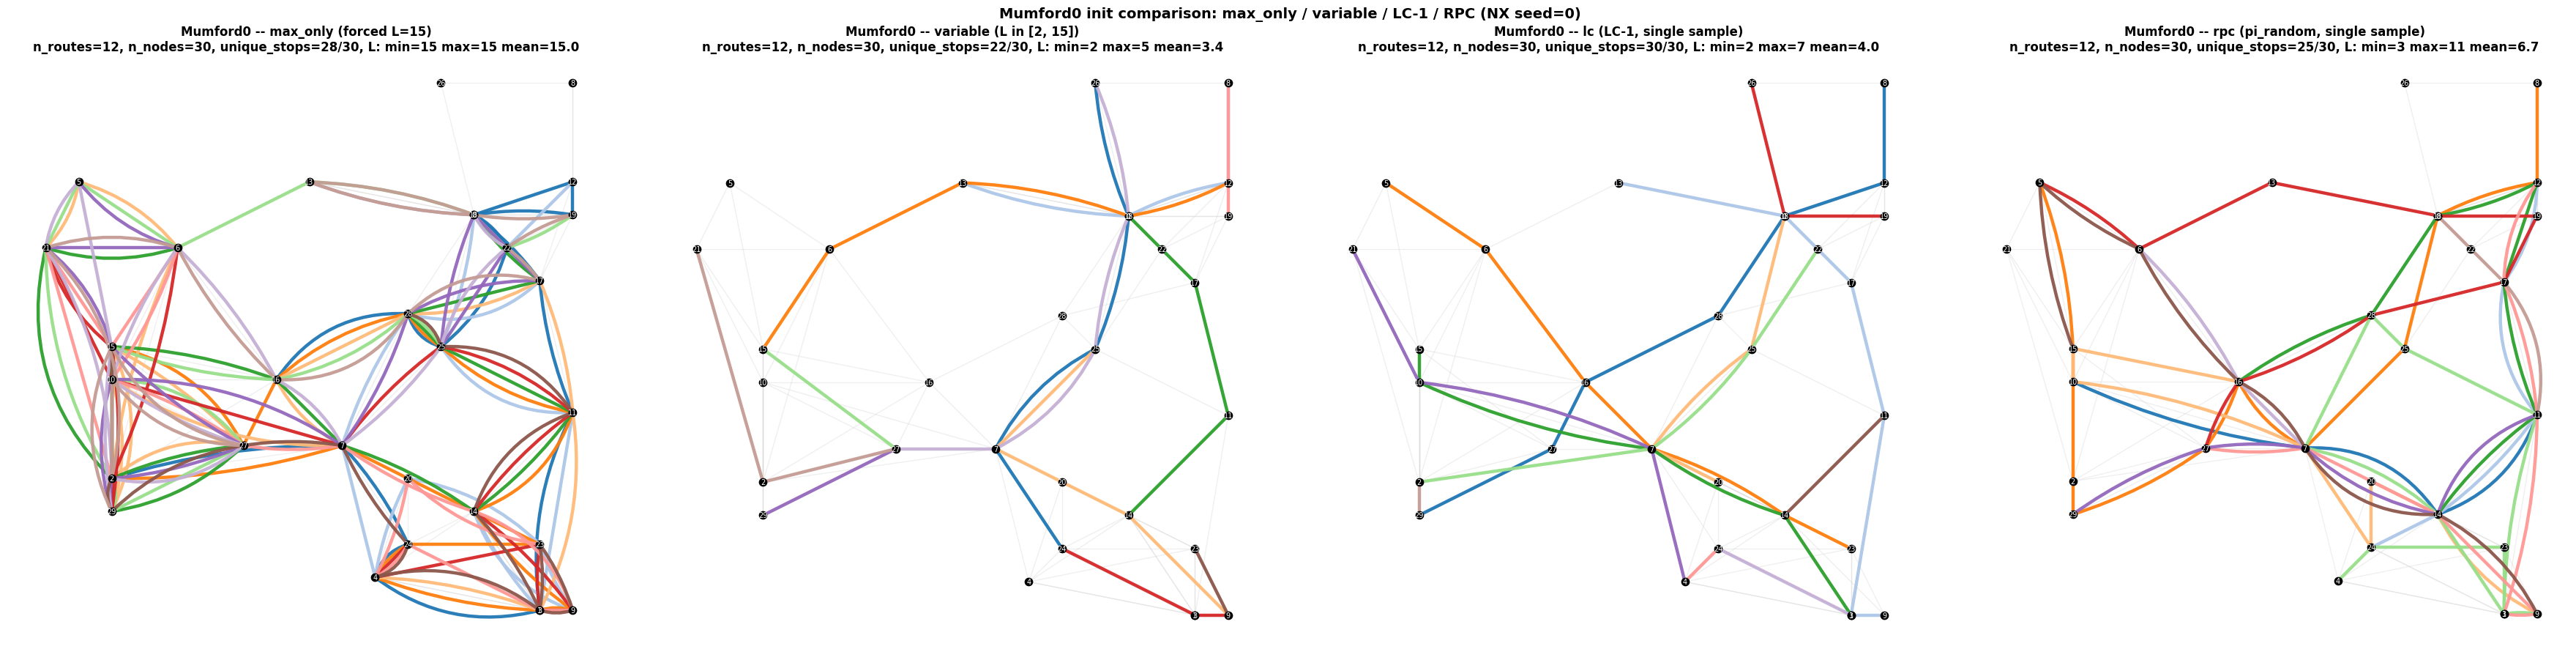

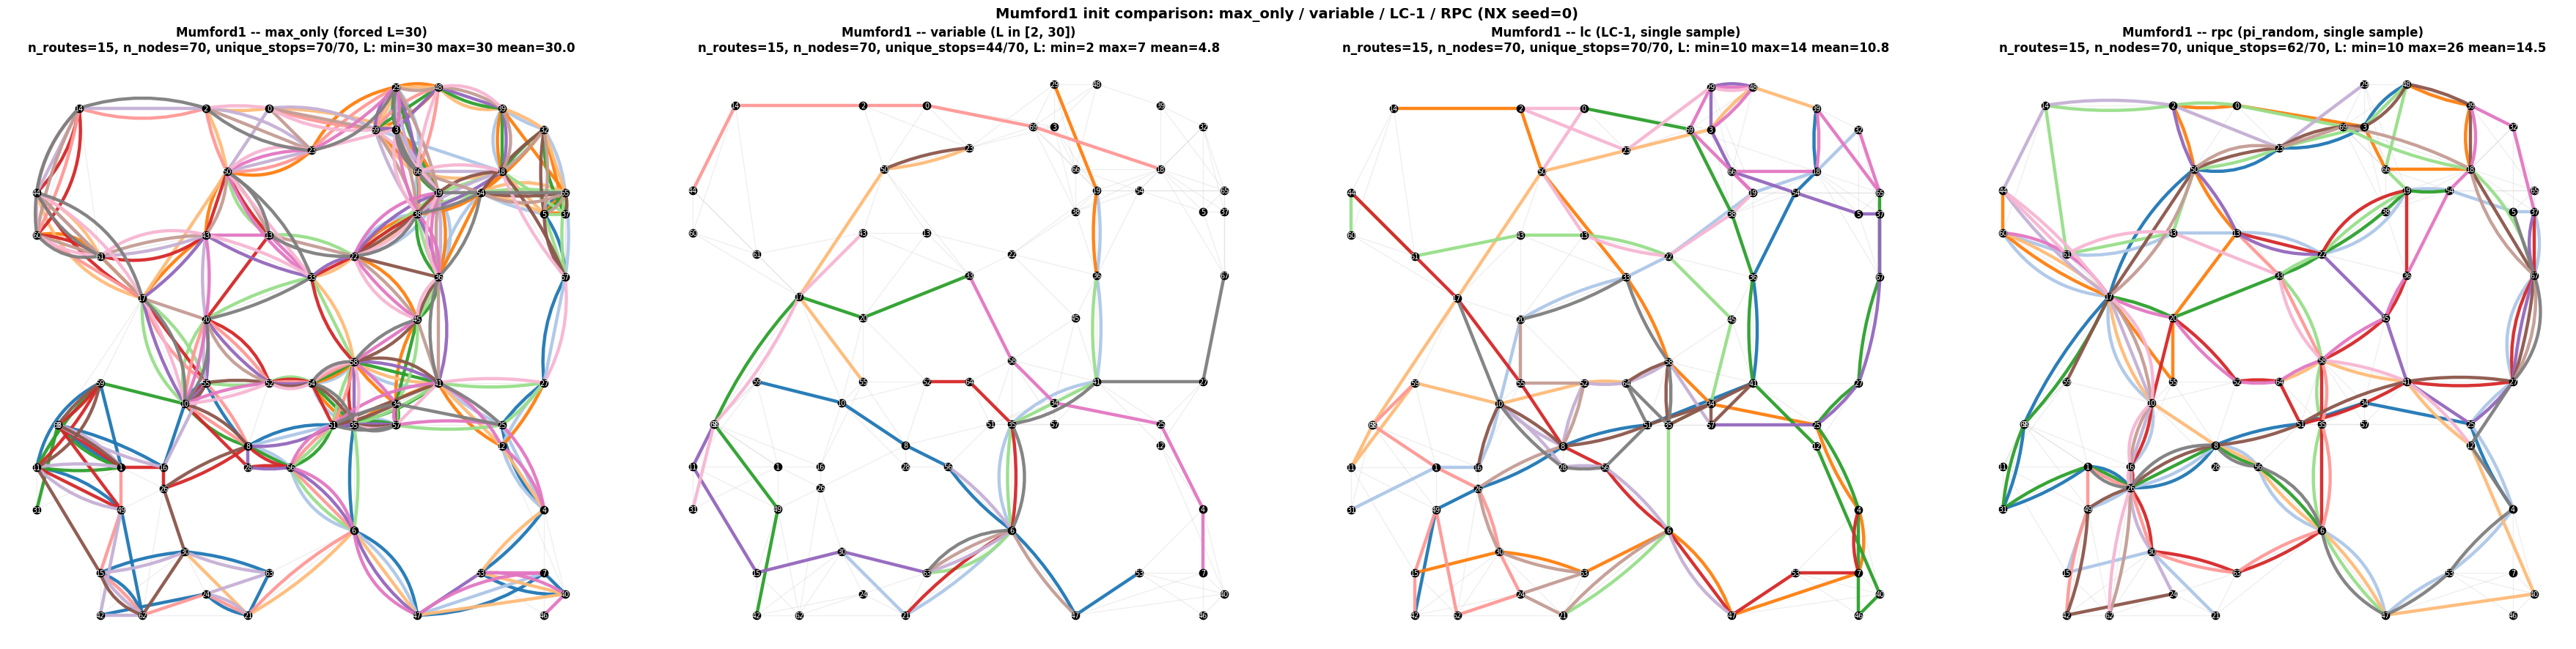

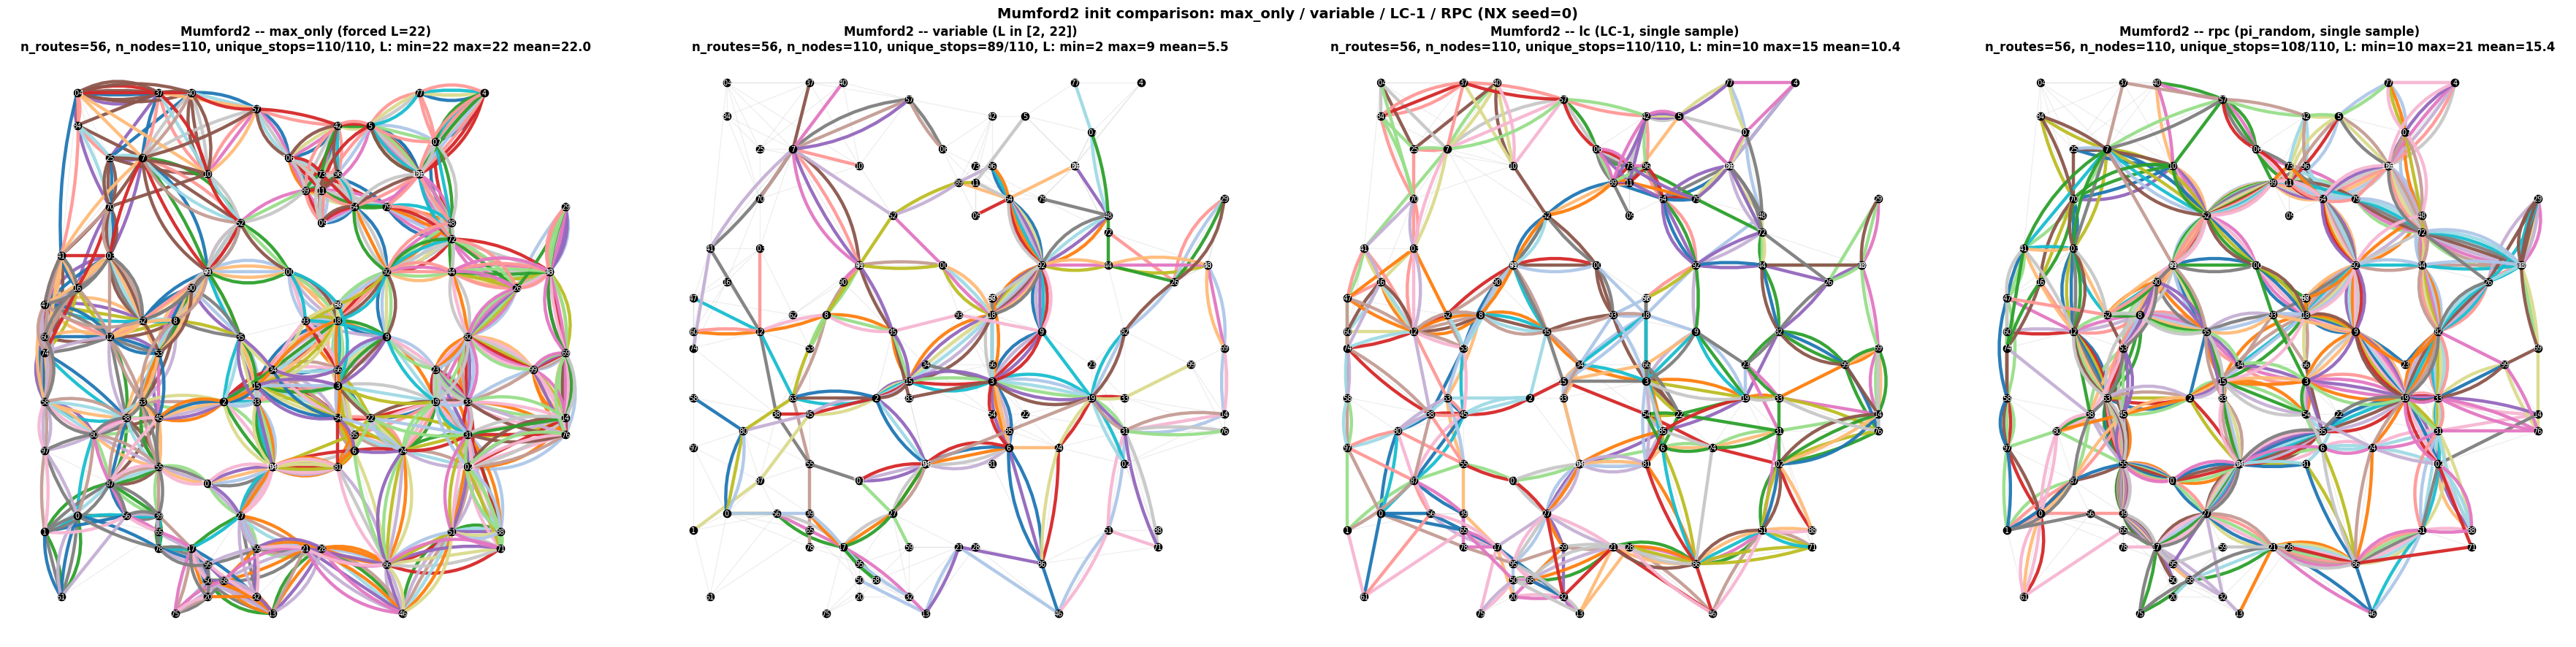

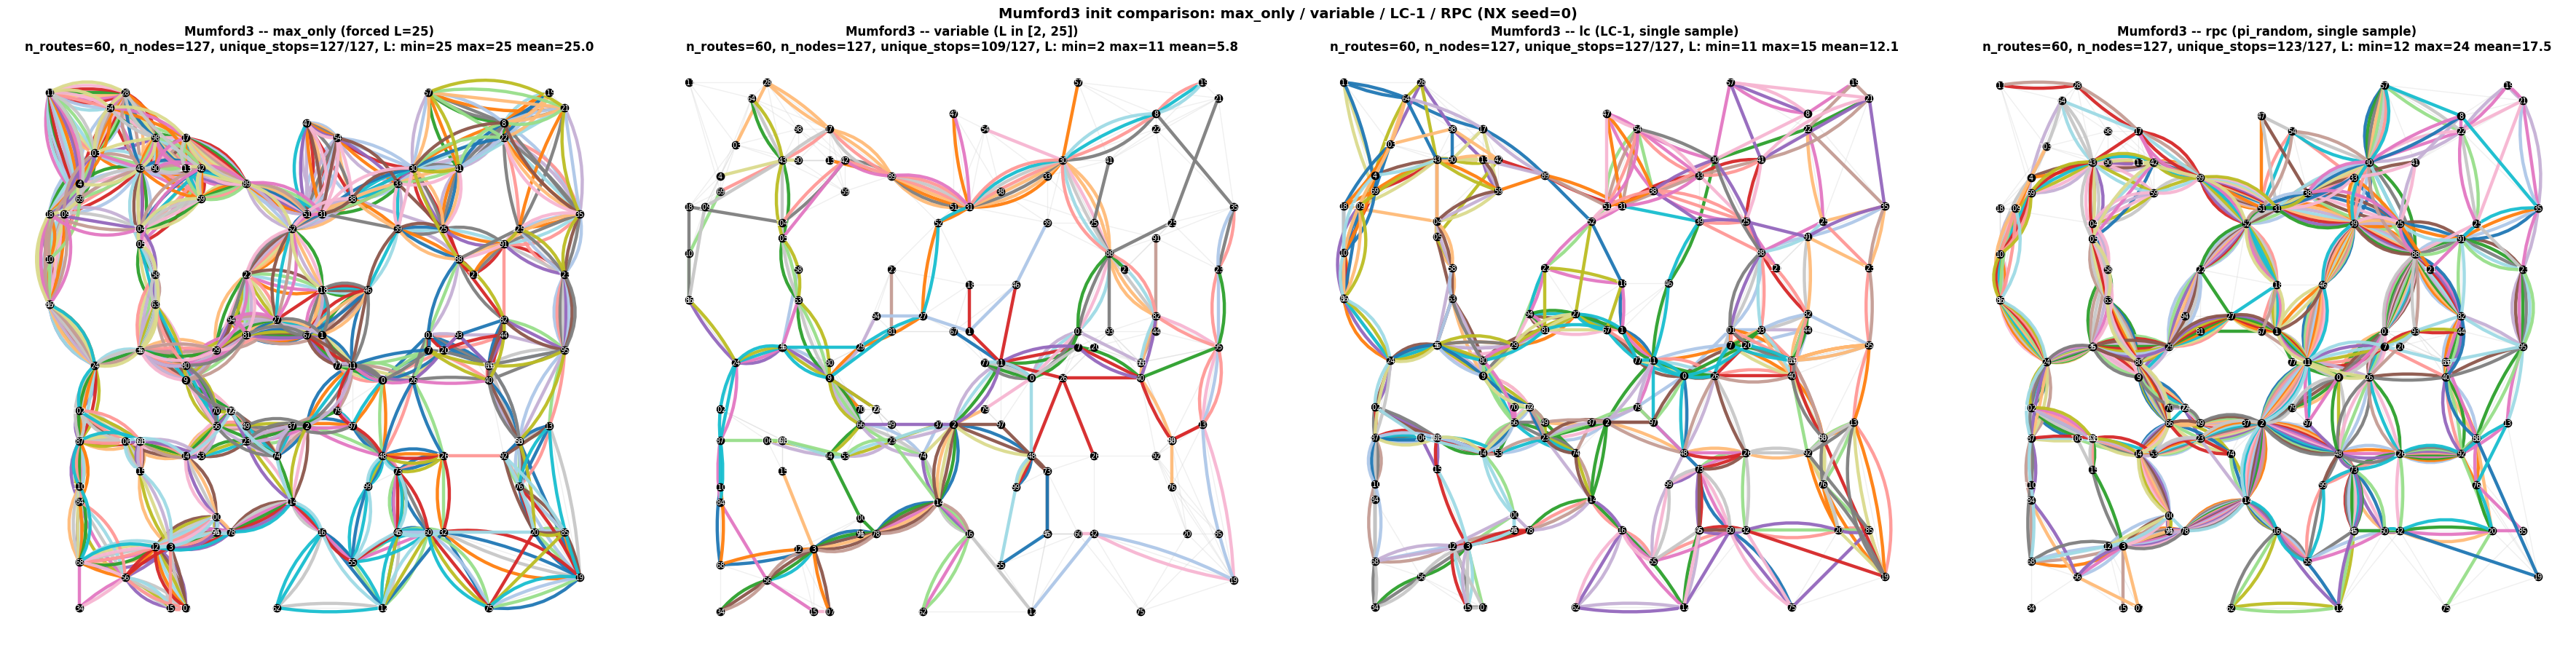

In [4]:
import torch as _torch_for_fig

def _route_stats(routes):
    """Return (min_len, max_len, mean_len, n_unique_stops) from a [1, R, L] tensor."""
    t = routes[0]
    lens = (t > -1).sum(dim=-1)
    unique = _torch_for_fig.unique(t[t > -1])
    return (int(lens.min().item()), int(lens.max().item()),
            float(lens.float().mean().item()), int(unique.numel()))


def _draw_panel(ax, routes, tensors, title, subtitle):
    """Common per-panel renderer; handles None routes by drawing a placeholder."""
    if routes is None:
        ax.text(0.5, 0.5, subtitle, ha="center", va="center",
                fontsize=12, transform=ax.transAxes)
        ax.set_title(title, fontweight="bold")
        ax.axis("off")
        return
    _plots.plot_plain_route_set(
        ax, routes, tensors["node_locs"], tensors["street_adj"],
        title=title, subtitle=subtitle,
        palette="tab20",
        with_overlap_curves=SHOW_OVERLAP_CURVES,
    )


for city, out in city_outputs.items():
    spec = out["spec"]
    tensors = out["tensors"]
    n_nodes = out["n_nodes"]

    fig, axes = plt.subplots(1, 4, figsize=(36, 9))

    # Panel 0: max_only
    mn, mx, mean, unique = _route_stats(out["routes_max_only"])
    _draw_panel(axes[0], out["routes_max_only"], tensors,
                title=f"{city} -- max_only (forced L={spec['max_route_len']})",
                subtitle=(f"n_routes={spec['n_routes']}, n_nodes={n_nodes}, "
                          f"unique_stops={unique}/{n_nodes}, "
                          f"L: min={mn} max={mx} mean={mean:.1f}"))

    # Panel 1: variable
    mn, mx, mean, unique = _route_stats(out["routes_variable"])
    _draw_panel(axes[1], out["routes_variable"], tensors,
                title=f"{city} -- variable (L in [{VARIABLE_MIN_LEN}, {spec['max_route_len']}])",
                subtitle=(f"n_routes={spec['n_routes']}, n_nodes={n_nodes}, "
                          f"unique_stops={unique}/{n_nodes}, "
                          f"L: min={mn} max={mx} mean={mean:.1f}"))

    # Panel 2: lc (skipped if MODEL_WEIGHTS_PATH missing)
    if out["routes_lc"] is not None:
        mn, mx, mean, unique = _route_stats(out["routes_lc"])
        sub = (f"n_routes={spec['n_routes']}, n_nodes={n_nodes}, "
               f"unique_stops={unique}/{n_nodes}, "
               f"L: min={mn} max={mx} mean={mean:.1f}")
    else:
        sub = "(LC skipped: MODEL_WEIGHTS_PATH missing)"
    _draw_panel(axes[2], out["routes_lc"], tensors,
                title=f"{city} -- lc (LC-1, single sample)",
                subtitle=sub)

    # Panel 3: rpc
    if out["routes_rpc"] is not None:
        mn, mx, mean, unique = _route_stats(out["routes_rpc"])
        sub = (f"n_routes={spec['n_routes']}, n_nodes={n_nodes}, "
               f"unique_stops={unique}/{n_nodes}, "
               f"L: min={mn} max={mx} mean={mean:.1f}")
    else:
        sub = "(RPC skipped)"
    _draw_panel(axes[3], out["routes_rpc"], tensors,
                title=f"{city} -- rpc (pi_random, single sample)",
                subtitle=sub)

    fig.suptitle(
        f"{city} init comparison: max_only / variable / LC-1 / RPC "
        f"(NX seed={NX_SEED})",
        fontsize=14, fontweight="bold")
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()
    plt.close(fig)

## 9. Variable `min_len` ablation on Mumford0

Demonstrates how the `min_len` floor of `build_variable_length_routes`
controls the built-route mean length. Each panel uses the same Mumford0
graph and the same `seed = NX_SEED`; only the `min_len` parameter
varies. As `min_len` rises:

* The candidate-pool shrinks (fewer shortest-paths qualify -- their
  natural length must be at least `min_len`).
* The built mean length rises.
* Above the graph diameter (~7 for Mumford0) the pool dries up and the
  picker falls back to repeated routes; coverage degrades.

This is the practical knob if you want to control the typical route
length in the `variable` variant without forcing every route to be
exactly `max_len` like `max_only` does.

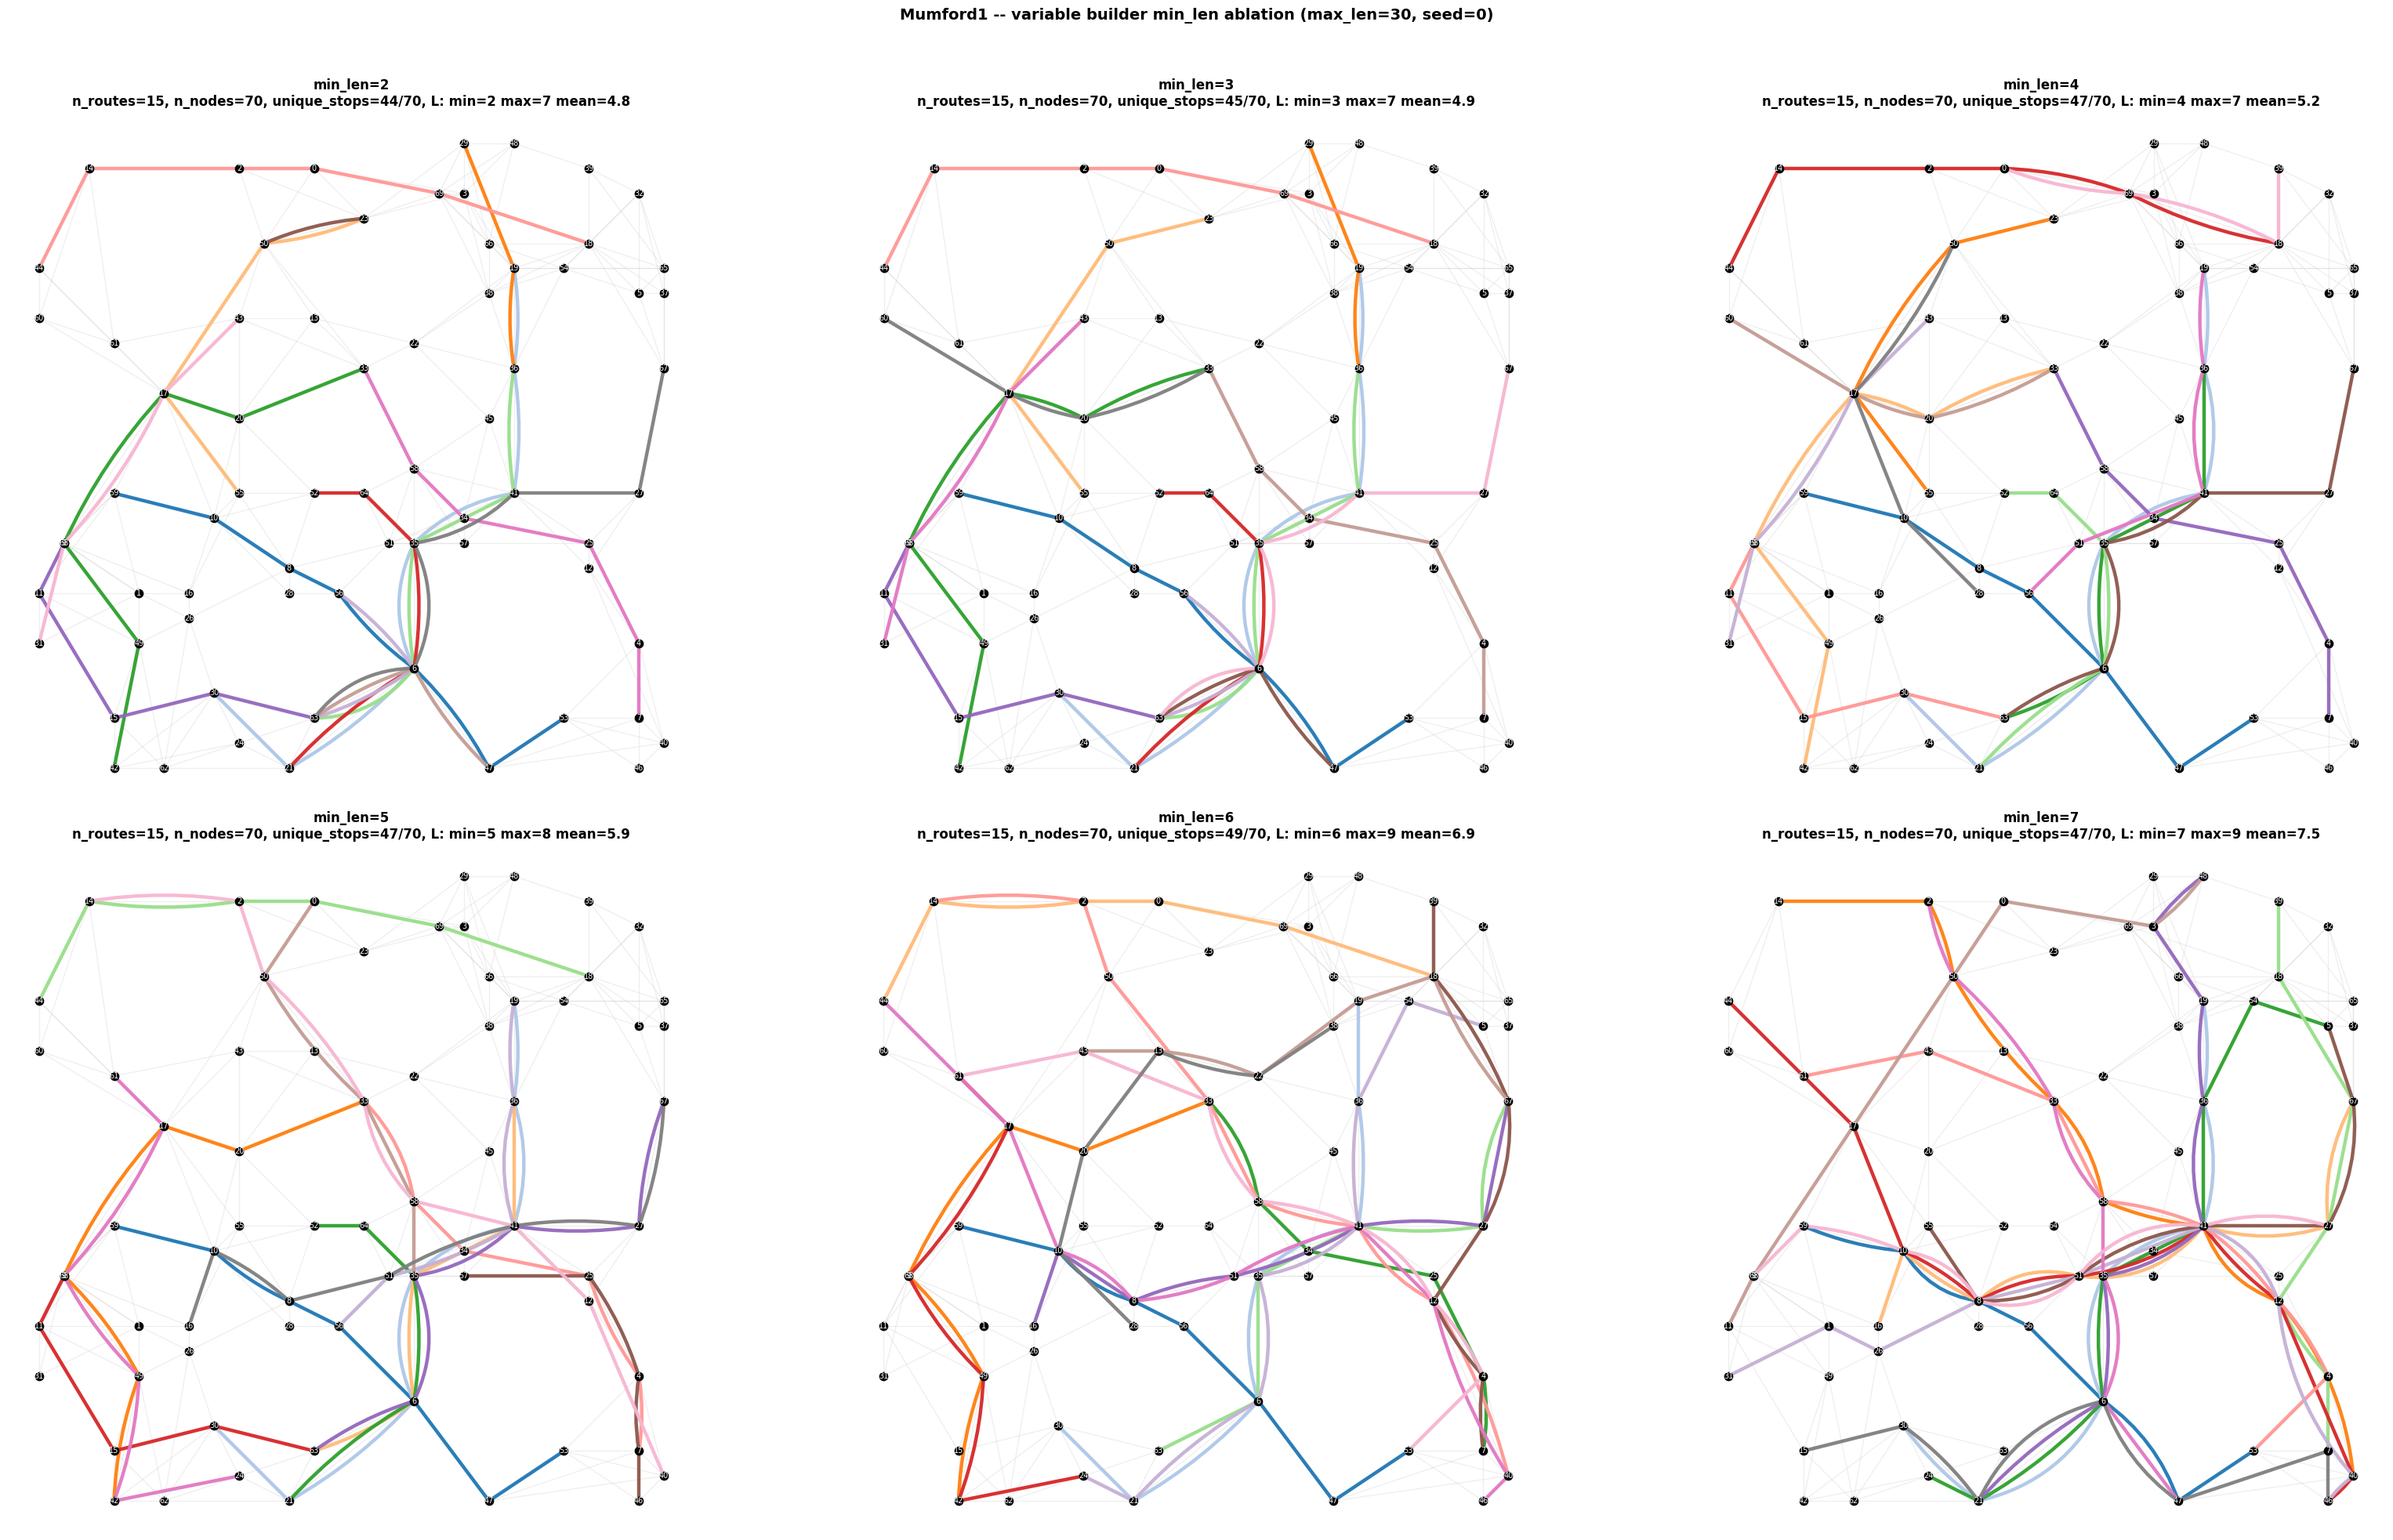

[results] table (6 rows) -> D:\PythonProjects\connectpt\artifacts\results\benchmark_init_minlen_ablation.csv


,min_len,status,built_min,built_max,built_mean,unique_stops,isolated_stops
0,2,ok,2,7,4.800,44,26
1,3,ok,3,7,4.933,45,25
2,4,ok,4,7,5.200,47,23
3,5,ok,5,8,5.933,47,23
4,6,ok,6,9,6.867,49,21
5,7,ok,7,9,7.533,47,23


In [5]:
MIN_LEN_ABLATION_VALUES = [2, 3, 4, 5, 6, 7]
MIN_LEN_ABLATION_CITY = "Mumford1"

# Reuse the city tensors already in city_outputs when present, else build them.
_ablation_spec = next(s for s in BENCHMARK_SPECS if s["city"] == MIN_LEN_ABLATION_CITY)
if MIN_LEN_ABLATION_CITY in city_outputs:
    _ablation_tensors = city_outputs[MIN_LEN_ABLATION_CITY]["tensors"]
else:
    _ablation_tensors = load_benchmark_tensors(MIN_LEN_ABLATION_CITY)
_ablation_graph = CityGraphData.from_tensors(
    _ablation_tensors["node_locs"], _ablation_tensors["street_adj"],
    _ablation_tensors["demand"], pos_only=False)
_ablation_n_nodes = int(_ablation_tensors["node_locs"].shape[0])

ablation_outputs = {}
for floor in MIN_LEN_ABLATION_VALUES:
    try:
        routes = build_variable_length_routes(
            _ablation_graph, num_routes=_ablation_spec["n_routes"],
            min_len=floor, max_len=_ablation_spec["max_route_len"],
            seed=NX_SEED)
        ablation_outputs[floor] = routes
    except ValueError as exc:
        print(f"  [min_len={floor}] FAILED: {exc}")
        ablation_outputs[floor] = None

# Grid layout: 1 row x N columns
n_panels = len(MIN_LEN_ABLATION_VALUES)
n_cols = min(n_panels, 3)
n_rows = math.ceil(n_panels / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(11 * n_cols, 10 * n_rows),
                          squeeze=False)
for i, floor in enumerate(MIN_LEN_ABLATION_VALUES):
    ax = axes[i // n_cols, i % n_cols]
    routes = ablation_outputs[floor]
    if routes is None:
        ax.text(0.5, 0.5, f"min_len={floor}: candidate pool exhausted",
                ha="center", va="center", fontsize=14, transform=ax.transAxes)
        ax.set_title(f"min_len={floor} (FAILED)", fontweight="bold")
        ax.axis("off")
        continue
    mn, mx, mean, unique = _route_stats(routes)
    _plots.plot_plain_route_set(
        ax, routes, _ablation_tensors["node_locs"], _ablation_tensors["street_adj"],
        title=f"min_len={floor}",
        subtitle=(f"n_routes={_ablation_spec['n_routes']}, "
                  f"n_nodes={_ablation_n_nodes}, "
                  f"unique_stops={unique}/{_ablation_n_nodes}, "
                  f"L: min={mn} max={mx} mean={mean:.1f}"),
        palette="tab20",
        with_overlap_curves=SHOW_OVERLAP_CURVES,
    )
# Hide leftover axes if grid is not full
for j in range(n_panels, n_rows * n_cols):
    axes[j // n_cols, j % n_cols].axis("off")

fig.suptitle(
    f"{MIN_LEN_ABLATION_CITY} -- variable builder min_len ablation "
    f"(max_len={_ablation_spec['max_route_len']}, seed={NX_SEED})",
    fontsize=14, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()
plt.close(fig)

# Quick stats table for the same sweep -- regenerate easily from the
# `ablation_outputs` dict above; saved to the same results folder.
ablation_rows = []
for floor in MIN_LEN_ABLATION_VALUES:
    routes = ablation_outputs[floor]
    if routes is None:
        ablation_rows.append({"min_len": floor, "status": "FAILED"})
        continue
    rt = routes[0]
    lens = (rt > -1).sum(dim=-1)
    unique = torch.unique(rt[rt > -1]).numel()
    ablation_rows.append({
        "min_len": floor,
        "status": "ok",
        "built_min": int(lens.min().item()),
        "built_max": int(lens.max().item()),
        "built_mean": float(lens.float().mean().item()),
        "unique_stops": unique,
        "isolated_stops": _ablation_n_nodes - unique,
    })
ablation_df = pd.DataFrame(ablation_rows)
save_table(ablation_df, "benchmark_init_minlen_ablation")
display(ablation_df.round(3))